# Dataset analysis

Hero pick counts and win rates across complete parsed matches.

In [17]:
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module

importlib.reload(dataset_module)

DatasetMaker = dataset_module.DatasetMaker
HERO_ALIASES = dataset_module.HERO_ALIASES
HEROES_PATH = dataset_module.HEROES_PATH
normalize_hero_name = dataset_module.normalize_hero_name

In [18]:
HERO_PICK_STATS_QUERY = """
    WITH complete_matches AS (
        SELECT
            m.match_id
        FROM dotabuff_matches m
        JOIN dotabuff_match_players p ON p.match_id = m.match_id
        WHERE
            m.winner_side IN ('radiant', 'dire')
            AND p.side IN ('radiant', 'dire')
            AND p.hero_slug IS NOT NULL
        GROUP BY m.match_id
        HAVING
            COUNT(*) = 10
            AND COUNT(*) FILTER (WHERE p.side = 'radiant') = 5
            AND COUNT(*) FILTER (WHERE p.side = 'dire') = 5
    )
    SELECT
        p.hero_slug,
        COUNT(*)::int AS appearances,
        COUNT(*) FILTER (WHERE p.side = m.winner_side)::int AS wins,
        COUNT(*) FILTER (WHERE p.side = 'radiant')::int AS radiant_picks,
        COUNT(*) FILTER (WHERE p.side = 'dire')::int AS dire_picks,
        COUNT(*) FILTER (WHERE p.side = 'radiant' AND m.winner_side = 'radiant')::int AS radiant_wins,
        COUNT(*) FILTER (WHERE p.side = 'dire' AND m.winner_side = 'dire')::int AS dire_wins
    FROM complete_matches cm
    JOIN dotabuff_matches m ON m.match_id = cm.match_id
    JOIN dotabuff_match_players p ON p.match_id = cm.match_id
    WHERE
        p.side IN ('radiant', 'dire')
        AND p.hero_slug IS NOT NULL
    GROUP BY p.hero_slug
    ORDER BY appearances DESC
"""

In [19]:
def load_hero_name_by_key(path=HEROES_PATH):
    heroes = json.loads(Path(path).read_text(encoding="utf-8"))
    names = {}

    for hero in heroes.values():
        localized_name = hero.get("localized_name")
        internal_name = hero.get("name")
        if not localized_name:
            continue

        names[normalize_hero_name(localized_name)] = localized_name
        if internal_name:
            short_name = internal_name.removeprefix("npc_dota_hero_")
            names[normalize_hero_name(short_name)] = localized_name

    return names


hero_name_by_key = load_hero_name_by_key()


def canonical_hero_key(value):
    key = normalize_hero_name(value)
    return HERO_ALIASES.get(key, key)


def hero_display_name(canonical_key):
    return hero_name_by_key.get(canonical_key, canonical_key)

In [20]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    with dataset._conn.cursor() as cur:
        cur.execute(HERO_PICK_STATS_QUERY)
        rows = cur.fetchall()

raw_stats = pd.DataFrame(rows)
raw_stats.head(), raw_stats.shape

(  hero_slug  appearances  wins  radiant_picks  dire_picks  radiant_wins  \
 0    jakiro          528   242            246         282           116   
 1      tiny          462   229            216         246           107   
 2  hoodwink          415   223            212         203           117   
 3      tusk          405   192            210         195           104   
 4   phoenix          402   212            197         205           106   
 
    dire_wins  
 0        126  
 1        122  
 2        106  
 3         88  
 4        106  ,
 (127, 7))

In [22]:
stats = raw_stats.copy()
stats["hero_key"] = stats["hero_slug"].map(canonical_hero_key)

hero_stats = (
    stats.groupby("hero_key", as_index=False)[
        ["appearances", "wins", "radiant_picks", "dire_picks", "radiant_wins", "dire_wins"]
    ]
    .sum()
    .assign(
        hero=lambda df: df["hero_key"].map(hero_display_name),
        win_rate=lambda df: df["wins"] / df["appearances"],
        radiant_win_rate=lambda df: df["radiant_wins"] / df["radiant_picks"].where(df["radiant_picks"] > 0),
        dire_win_rate=lambda df: df["dire_wins"] / df["dire_picks"].where(df["dire_picks"] > 0),
    )
    .sort_values(["appearances", "win_rate"], ascending=[False, False])
)

hero_stats = hero_stats[
    [
        "hero",
        "hero_key",
        "appearances",
        "wins",
        "win_rate",
        "radiant_picks",
        "radiant_wins",
        "radiant_win_rate",
        "dire_picks",
        "dire_wins",
        "dire_win_rate",
    ]
]

hero_stats.head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
42,Jakiro,jakiro,528,242,0.458333,246,116,0.471545,282,126,0.446809
108,Tiny,tiny,462,229,0.495671,216,107,0.495370,246,122,0.495935
38,Hoodwink,hoodwink,415,223,0.537349,212,117,0.551887,203,106,0.522167
111,Tusk,tusk,405,192,0.474074,210,104,0.495238,195,88,0.451282
78,Phoenix,phoenix,402,212,0.527363,197,106,0.538071,205,106,0.517073
120,Warlock,warlock,363,177,0.487603,168,74,0.440476,195,103,0.528205
32,Ember Spirit,emberspirit,358,193,0.539106,185,93,0.502703,173,100,0.578035
80,Puck,puck,343,165,0.481050,173,82,0.473988,170,83,0.488235
89,Shadow Demon,shadowdemon,336,189,0.562500,167,95,0.568862,169,94,0.556213
8,Beastmaster,beastmaster,312,152,0.487179,173,88,0.508671,139,64,0.460432


In [23]:
hero_stats.tail(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
29,Earthshaker,earthshaker,20,11,0.550000,9,4,0.444444,11,7,0.636364
28,Drow Ranger,drowranger,18,6,0.333333,10,4,0.400000,8,2,0.250000
24,Death Prophet,deathprophet,17,9,0.529412,12,8,0.666667,5,1,0.200000
57,Magnus,magnus,15,8,0.533333,7,4,0.571429,8,4,0.500000
126,Zeus,zeus,13,7,0.538462,6,4,0.666667,7,3,0.428571
52,Lina,lina,13,5,0.384615,5,2,0.400000,8,3,0.375000
77,Phantom Lancer,phantomlancer,13,5,0.384615,8,5,0.625000,5,0,0.000000
124,Witch Doctor,witchdoctor,12,7,0.583333,6,4,0.666667,6,3,0.500000
48,Legion Commander,legioncommander,10,7,0.700000,6,4,0.666667,4,3,0.750000
31,Elder Titan,eldertitan,9,3,0.333333,5,2,0.400000,4,1,0.250000


In [24]:
summary = {
    "unique_raw_hero_slugs": raw_stats["hero_slug"].nunique(),
    "unique_canonical_heroes": hero_stats["hero_key"].nunique(),
    "total_hero_appearances": int(hero_stats["appearances"].sum()),
    "complete_matches": int(hero_stats["appearances"].sum() / 10),
}

summary

{'unique_raw_hero_slugs': 127,
 'unique_canonical_heroes': 127,
 'total_hero_appearances': 15880,
 'complete_matches': 1588}

In [25]:
hero_stats.sort_values("appearances", ascending=False).head(30)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
42,Jakiro,jakiro,528,242,0.458333,246,116,0.471545,282,126,0.446809
108,Tiny,tiny,462,229,0.495671,216,107,0.495370,246,122,0.495935
38,Hoodwink,hoodwink,415,223,0.537349,212,117,0.551887,203,106,0.522167
111,Tusk,tusk,405,192,0.474074,210,104,0.495238,195,88,0.451282
78,Phoenix,phoenix,402,212,0.527363,197,106,0.538071,205,106,0.517073
120,Warlock,warlock,363,177,0.487603,168,74,0.440476,195,103,0.528205
32,Ember Spirit,emberspirit,358,193,0.539106,185,93,0.502703,173,100,0.578035
80,Puck,puck,343,165,0.481050,173,82,0.473988,170,83,0.488235
89,Shadow Demon,shadowdemon,336,189,0.562500,167,95,0.568862,169,94,0.556213
8,Beastmaster,beastmaster,312,152,0.487179,173,88,0.508671,139,64,0.460432


In [33]:
MIN_APPEARANCES = 0

popular_heroes = hero_stats[hero_stats["appearances"] >= MIN_APPEARANCES]
popular_heroes.sort_values("win_rate", ascending=False).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
115,Vengeful Spirit,vengefulspirit,2,2,1.000000,0,0,NaN,2,2,1.000000
54,Lone Druid,lonedruid,44,32,0.727273,12,10,0.833333,32,22,0.687500
9,Bloodseeker,bloodseeker,7,5,0.714286,2,2,1.000000,5,3,0.600000
48,Legion Commander,legioncommander,10,7,0.700000,6,4,0.666667,4,3,0.750000
4,Arc Warden,arcwarden,3,2,0.666667,2,1,0.500000,1,1,1.000000
13,Broodmother,broodmother,26,17,0.653846,9,8,0.888889,17,9,0.529412
109,Treant Protector,treantprotector,193,122,0.632124,80,55,0.687500,113,67,0.592920
39,Huskar,huskar,92,57,0.619565,45,26,0.577778,47,31,0.659574
123,Winter Wyvern,winterwyvern,34,21,0.617647,14,12,0.857143,20,9,0.450000
61,Meepo,meepo,23,14,0.608696,12,6,0.500000,11,8,0.727273


In [34]:
popular_heroes.sort_values("win_rate", ascending=True).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
74,Outworld Devourer,outworlddevourer,2,0,0.000000,2,0,0.000000,0,0,NaN
15,Chaos Knight,chaosknight,3,0,0.000000,0,0,NaN,3,0,0.000000
3,Anti-Mage,antimage,8,1,0.125000,4,0,0.000000,4,1,0.250000
31,Elder Titan,eldertitan,9,3,0.333333,5,2,0.400000,4,1,0.250000
28,Drow Ranger,drowranger,18,6,0.333333,10,4,0.400000,8,2,0.250000
113,Undying,undying,38,14,0.368421,22,7,0.318182,16,7,0.437500
22,Dawnbreaker,dawnbreaker,51,19,0.372549,32,12,0.375000,19,7,0.368421
97,Sniper,sniper,48,18,0.375000,27,10,0.370370,21,8,0.380952
55,Luna,luna,121,46,0.380165,59,26,0.440678,62,20,0.322581
77,Phantom Lancer,phantomlancer,13,5,0.384615,8,5,0.625000,5,0,0.000000


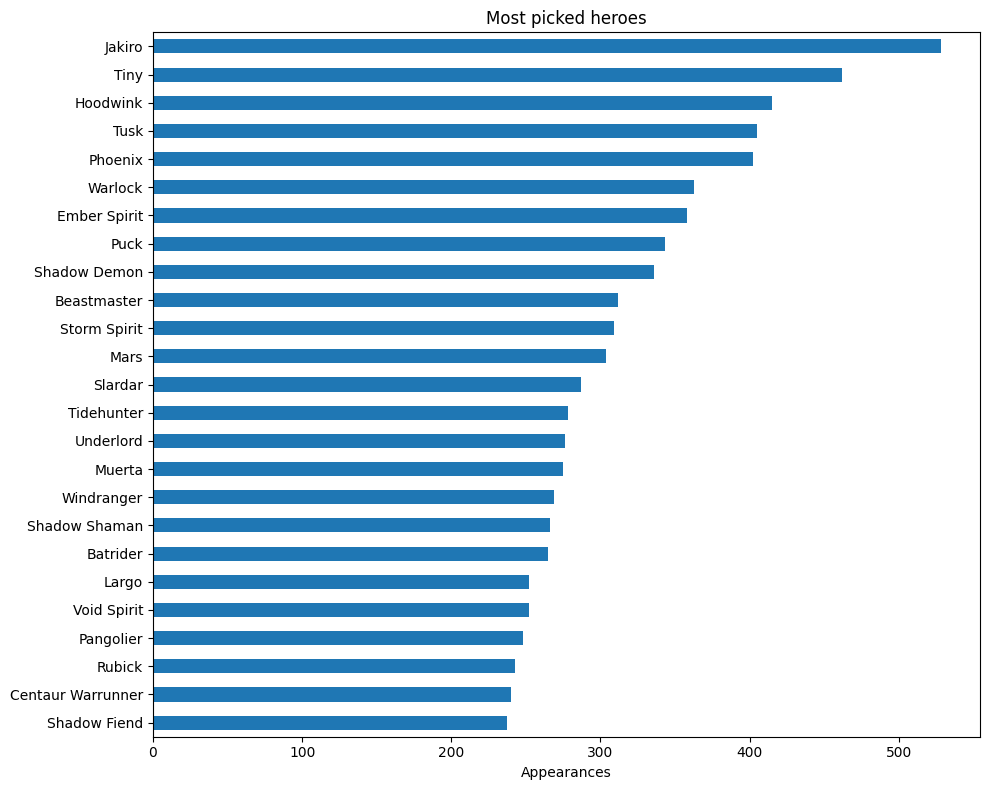

In [35]:
top_picked = hero_stats.sort_values("appearances", ascending=False).head(25).sort_values("appearances")

ax = top_picked.plot.barh(x="hero", y="appearances", figsize=(10, 8), legend=False)
ax.set_title("Most picked heroes")
ax.set_xlabel("Appearances")
ax.set_ylabel("")
plt.tight_layout()

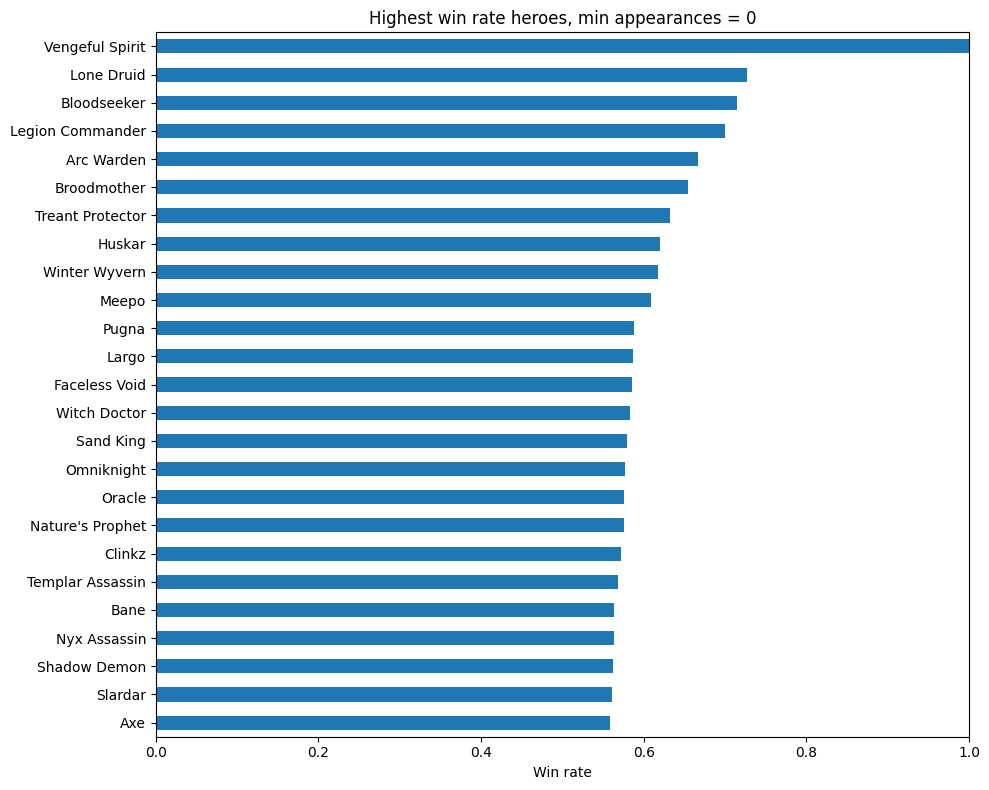

In [36]:
top_win_rate = popular_heroes.sort_values("win_rate", ascending=False).head(25).sort_values("win_rate")

ax = top_win_rate.plot.barh(x="hero", y="win_rate", figsize=(10, 8), legend=False)
ax.set_title(f"Highest win rate heroes, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()

## Histograms

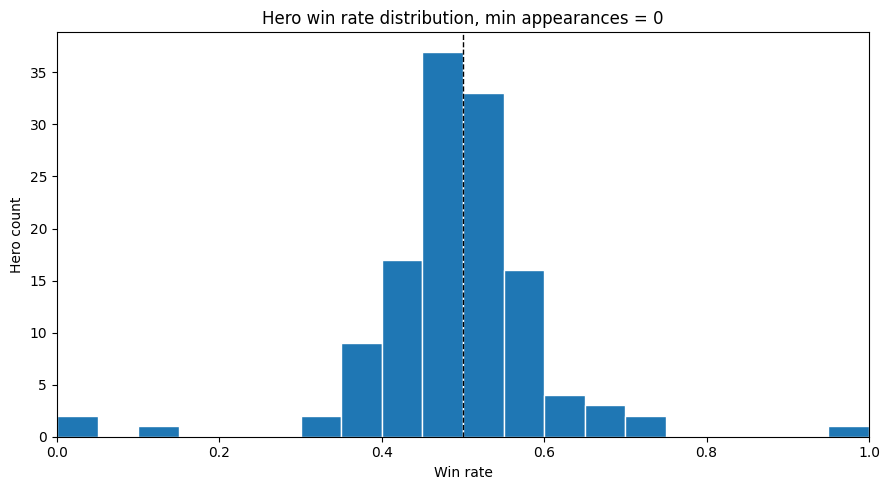

In [37]:
ax = popular_heroes["win_rate"].plot.hist(bins=20, figsize=(9, 5), edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Hero win rate distribution, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("Hero count")
ax.set_xlim(0, 1)
plt.tight_layout()

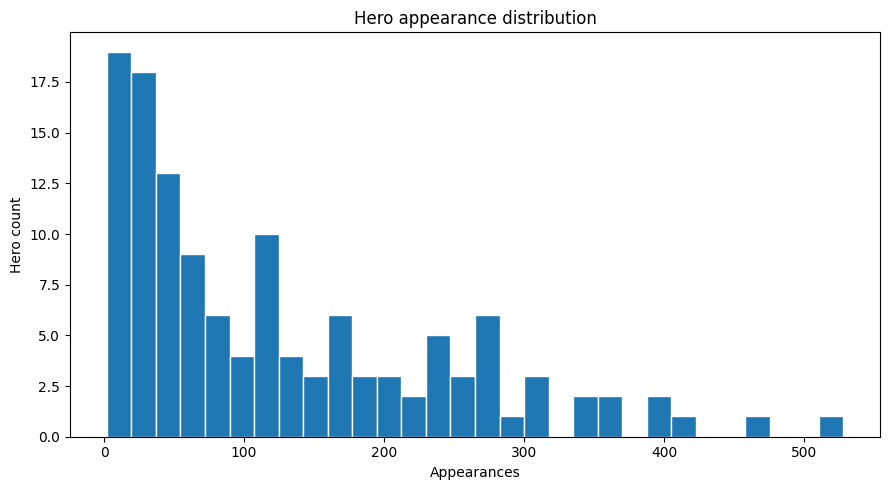

In [31]:
ax = hero_stats["appearances"].plot.hist(bins=30, figsize=(9, 5), edgecolor="white")
ax.set_title("Hero appearance distribution")
ax.set_xlabel("Appearances")
ax.set_ylabel("Hero count")
plt.tight_layout()